# 3. Train a two-dimensional GAN


This notebook returns to the $d=2$ setting illustrated on p. 7 of the slides.

We use

$$
Z\in\mathbb R^{d'},\qquad G_\theta(Z)\in\mathbb R^2,
$$

and train the generator to reproduce a simple two-dimensional distribution with four modes.


In [16]:
import math
import random
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

SEED = 123
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device(
    "mps" if torch.backends.mps.is_available()
    else "cuda" if torch.cuda.is_available()
    else "cpu"
)

print("PyTorch version:", torch.__version__)
print("Device:", device)

PyTorch version: 2.2.1
Device: mps


## 1. Simulate observations $X_1,\ldots,X_n\in\mathbb R^2$

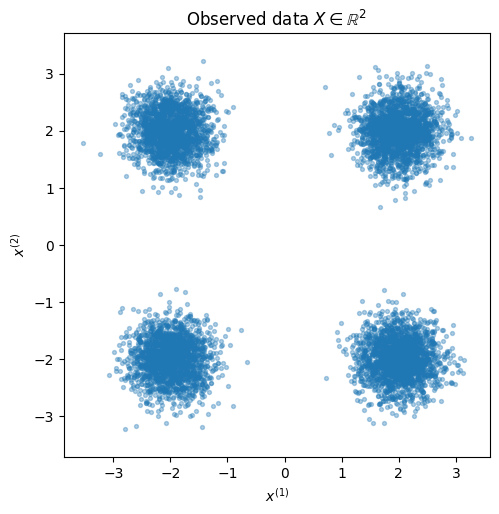

In [17]:
n = 8000
centres = torch.tensor([
    [-2.0, -2.0],
    [-2.0,  2.0],
    [ 2.0, -2.0],
    [ 2.0,  2.0]
])

labels = torch.randint(0, 4, (n,))
X = centres[labels] + 0.35 * torch.randn(n, 2)

plt.figure(figsize=(5.5, 5.5))
plt.scatter(X[:, 0], X[:, 1], s=8, alpha=0.35)
plt.xlabel(r"$x^{(1)}$")
plt.ylabel(r"$x^{(2)}$")
plt.title(r"Observed data $X\in\mathbb{R}^2$")
plt.axis("equal")
plt.show()

## 2. Generator and discriminator

We choose

$$
d'=3,\qquad d=2.
$$

Thus the generator maps a three-dimensional latent vector into a two-dimensional observation, exactly matching the dimensions in the diagram on p. 7. We use more than $J=4$ hidden units here so that training is easier to observe in a short practical.

In [33]:
d_prime = 3
d = 2
J = 64

class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_prime, J),
            nn.ReLU(),
            nn.Linear(J, J),
            nn.ReLU(),
            nn.Linear(J, d)
        )

    def forward(self, z):
        return self.net(z)

class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d, J),
            nn.LeakyReLU(0.2),
            nn.Linear(J, J),
            nn.LeakyReLU(0.2),
            nn.Linear(J, 1)
        )

    def forward(self, x):
        return self.net(x).squeeze(-1)

G = Generator().to(device)
D = Discriminator().to(device)

print(G)
print(D)

Generator(
  (net): Sequential(
    (0): Linear(in_features=3, out_features=4, bias=True)
    (1): ReLU()
    (2): Linear(in_features=4, out_features=4, bias=True)
    (3): ReLU()
    (4): Linear(in_features=4, out_features=2, bias=True)
  )
)
Discriminator(
  (net): Sequential(
    (0): Linear(in_features=2, out_features=4, bias=True)
    (1): LeakyReLU(negative_slope=0.2)
    (2): Linear(in_features=4, out_features=4, bias=True)
    (3): LeakyReLU(negative_slope=0.2)
    (4): Linear(in_features=4, out_features=1, bias=True)
  )
)


In [34]:
def sample_Z(n):
    return torch.randn(n, d_prime, device=device)

batch_size = 256
loader = DataLoader(TensorDataset(X), batch_size=batch_size,
                    shuffle=True, drop_last=True)

criterion = nn.BCEWithLogitsLoss()
opt_D = torch.optim.Adam(D.parameters(), lr=2e-4, betas=(0.5, 0.999))
opt_G = torch.optim.Adam(G.parameters(), lr=2e-4, betas=(0.5, 0.999))

## 3. A compact training loop

Each batch has two phases.

### Phase A: update $\phi$

Maximise the discriminator's ability to separate

$$
X\sim p_X
\quad\text{from}\quad
\widetilde X=G_\theta(Z).
$$

### Phase B: update $\theta$

Change the generator so that the discriminator treats $G_\theta(Z)$ as real.

In [35]:
def train_gan(epochs=150):
    history = {"D": [], "G": []}

    for epoch in range(epochs):
        d_epoch, g_epoch = [], []

        for (x_real,) in loader:
            x_real = x_real.to(device)
            batch_n = x_real.shape[0]

            # ---- Update discriminator phi ----
            z = sample_Z(batch_n)
            x_fake = G(z).detach()

            real_logits = D(x_real)
            fake_logits = D(x_fake)

            loss_D = (
                criterion(real_logits, torch.ones_like(real_logits))
                + criterion(fake_logits, torch.zeros_like(fake_logits))
            )

            opt_D.zero_grad()
            loss_D.backward()
            opt_D.step()

            # ---- Update generator theta ----
            z = sample_Z(batch_n)
            x_fake = G(z)
            fake_logits = D(x_fake)

            loss_G = criterion(fake_logits, torch.ones_like(fake_logits))

            opt_G.zero_grad()
            loss_G.backward()
            opt_G.step()

            d_epoch.append(loss_D.item())
            g_epoch.append(loss_G.item())

        history["D"].append(np.mean(d_epoch))
        history["G"].append(np.mean(g_epoch))

        if (epoch + 1) % 30 == 0:
            print(
                f"Epoch {epoch+1:3d}/{epochs} | "
                f"loss_D={history['D'][-1]:.3f} | "
                f"loss_G={history['G'][-1]:.3f}"
            )

    return history

history = train_gan()

Epoch  30/150 | loss_D=1.298 | loss_G=0.803
Epoch  60/150 | loss_D=1.052 | loss_G=0.957
Epoch  90/150 | loss_D=1.068 | loss_G=0.961
Epoch 120/150 | loss_D=1.296 | loss_G=0.813
Epoch 150/150 | loss_D=1.337 | loss_G=0.790


## 4. Compare real and generated samples

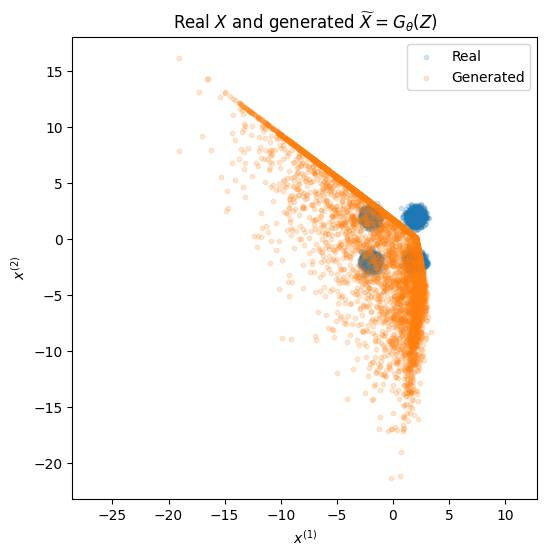

In [36]:
with torch.no_grad():
    X_fake = G(sample_Z(8000)).cpu()

plt.figure(figsize=(6, 6))
plt.scatter(X[:, 0], X[:, 1], s=10, alpha=0.18, label="Real")
plt.scatter(X_fake[:, 0], X_fake[:, 1], s=10, alpha=0.18, label="Generated")
plt.xlabel(r"$x^{(1)}$")
plt.ylabel(r"$x^{(2)}$")
plt.title(r"Real $X$ and generated $\widetilde X=G_\theta(Z)$")
plt.axis("equal")
plt.legend()
plt.show()

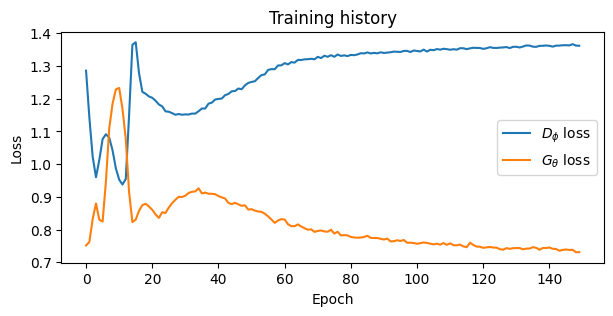

In [30]:
plt.figure(figsize=(7, 3))
plt.plot(history["D"], label=r"$D_\phi$ loss")
plt.plot(history["G"], label=r"$G_\theta$ loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training history")
plt.legend()
plt.show()

## 5. Look at the discriminator

A well-balanced GAN should eventually make discrimination difficult. We can inspect $D_\phi(x)$ over a grid.

Values near 1 indicate "real"; values near 0 indicate "generated".

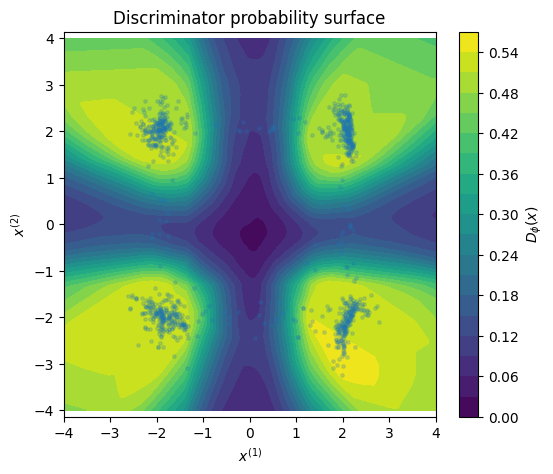

In [31]:
grid_1 = torch.linspace(-4, 4, 150)
grid_2 = torch.linspace(-4, 4, 150)
xx, yy = torch.meshgrid(grid_1, grid_2, indexing="xy")
grid = torch.stack([xx.reshape(-1), yy.reshape(-1)], dim=1).to(device)

with torch.no_grad():
    p_real = torch.sigmoid(D(grid)).cpu().reshape(150, 150)

plt.figure(figsize=(6, 5))
plt.contourf(xx.numpy(), yy.numpy(), p_real.numpy(), levels=20)
plt.colorbar(label=r"$D_\phi(x)$")
plt.scatter(X_fake[:1000, 0], X_fake[:1000, 1], s=6, alpha=0.2)
plt.xlabel(r"$x^{(1)}$")
plt.ylabel(r"$x^{(2)}$")
plt.title("Discriminator probability surface")
plt.axis("equal")
plt.show()

## 6. Workshop experiments

Try these one at a time.

**A. Latent dimension.** Set $d'=1$. Can a one-dimensional latent variable reproduce this two-dimensional distribution well?

**B. Network width.** Set $J=4$, matching the small architecture in the slide diagram. What changes?

**C. Discriminator strength.** Give the discriminator two or three updates for every generator update. Does training improve or become less stable?

**D. Mode collapse.** Repeat training with several random seeds. Does the generator always learn all four modes?

**E. Latent distribution.** Replace the Gaussian $\pi$ with a uniform distribution.

These experiments connect directly to the slide questions: *How should $\pi$ and $d'$ be chosen? How should $G$ be built?*